# PEOPLE ANALYTICS
### RICARDO PADILLA HERRERA - 110401

In [1]:
# Import numpy
import numpy as np
if not hasattr(np, "product"):
    np.product = np.prod

import numpy as np

_old_percentile = np.percentile
def _percentile_patched(a, q, *args, **kwargs):
    if "interpolation" in kwargs and "method" not in kwargs:
        kwargs["method"] = kwargs.pop("interpolation")
    return _old_percentile(a, q, *args, **kwargs)

np.percentile = _percentile_patched

In [2]:
# Import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pingouin as pg
from pyprocessmacro import Process

In [3]:
# Load Dataset
df = pd.read_csv("C:/Users/ricar/OneDrive/Desktop/EDHEC/SEMESTER 2/OPERATION ANALYSIS/ASSIGNMENT/Database_individual_assignment.csv")
df

,idnumber,workexperience,age,nationality,gender,selfa_t0,selfb_t0,selfc_t0,selfd_t0,selfe_t0,...,supporta_t4,supportb_t4,supportc_t4,supportd_t4,opena,openb,openc,opend,opene,openf
0,1,1,23,1,0,3,3,3,3,2,...,4,4,4,4,4,3,2,3,3,2
1,2,1,25,5,0,4,3,3,3,4,...,4,3,3,3,4,4,4,4,4,4
2,3,,22,2,0,,,,,,...,,,,,,,,,,
3,4,1,22,1,0,4,3,4,3,3,...,5,5,5,5,5,5,5,5,5,4
4,5,1,22,1,1,4,4,3,3,3,...,5,5,5,5,5,5,5,5,5,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
670,671,1,21,36,0,,,,,,...,4,4,4,4,4,4,4,5,5,2
671,672,1,20,10,1,2,3,3,3,2,...,3,4,4,4,4,3,2,4,4,3
672,673,2,21,15,1,4,3,4,3,3,...,5,5,5,5,5,5,3,5,4,3
673,674,1,22,21,0,4,3,4,4,4,...,4,4,4,4,4,4,4,4,4,3


### DATA CLEANING

In [4]:
# Check the data types
df.dtypes
df.isnull().sum(axis = 0)

idnumber          0
workexperience    0
age               0
nationality       0
gender            0
                 ..
openb             0
openc             0
opend             0
opene             0
openf             0
Length: 293, dtype: int64

In [5]:
# Replace missing values with Nan
df = df.replace(r'^\s*$', np.nan, regex=True)
df = df.replace('Missing', np.nan)
df

,idnumber,workexperience,age,nationality,gender,selfa_t0,selfb_t0,selfc_t0,selfd_t0,selfe_t0,...,supporta_t4,supportb_t4,supportc_t4,supportd_t4,opena,openb,openc,opend,opene,openf
0,1,1,23,1,0,3,3,3,3,2,...,4,4,4,4,4,3,2,3,3,2
1,2,1,25,5,0,4,3,3,3,4,...,4,3,3,3,4,4,4,4,4,4
2,3,NaN,22,2,0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,1,22,1,0,4,3,4,3,3,...,5,5,5,5,5,5,5,5,5,4
4,5,1,22,1,1,4,4,3,3,3,...,5,5,5,5,5,5,5,5,5,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
670,671,1,21,36,0,NaN,NaN,NaN,NaN,NaN,...,4,4,4,4,4,4,4,5,5,2
671,672,1,20,10,1,2,3,3,3,2,...,3,4,4,4,4,3,2,4,4,3
672,673,2,21,15,1,4,3,4,3,3,...,5,5,5,5,5,5,3,5,4,3
673,674,1,22,21,0,4,3,4,4,4,...,4,4,4,4,4,4,4,4,4,3


In [6]:
# Count the number of missing values
df.isnull().sum(axis = 0)

idnumber            0
workexperience    122
age                 0
nationality         0
gender              0
                 ... 
openb             122
openc             122
opend             122
opene             122
openf             122
Length: 293, dtype: int64

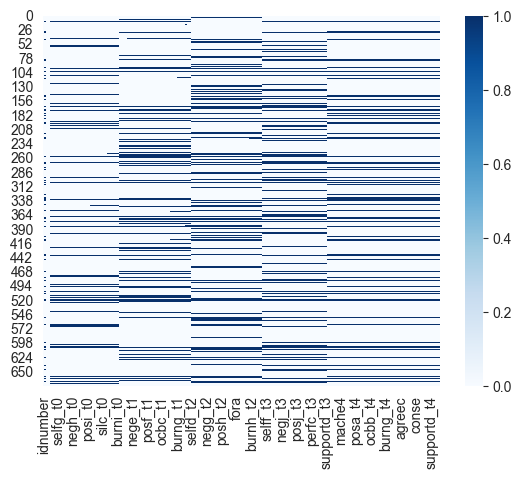

In [7]:
# Visualizes missing values in a heatmap
sns.heatmap(df.isnull(), cmap='Blues', cbar=True);

In [8]:
# Check the percentage of missing values in each column.
# A threshold of 30% was considered to decide whether to drop variables.
# Since no variable exceeds this threshold, no column was removed.
missing_pct = df.isnull().mean() * 100
missing_pct.sort_values(ascending = False)

burna_t2       22.962963
supportd_t2    22.962963
supportc_t2    22.962963
supportb_t2    22.962963
supporta_t2    22.962963
                 ...    
selfj_t0       15.111111
gender          0.000000
nationality     0.000000
age             0.000000
idnumber        0.000000
Length: 293, dtype: float64

In [9]:
# Deletion was applied to remove observations with missing values
df1 = df.dropna()
df1

,idnumber,workexperience,age,nationality,gender,selfa_t0,selfb_t0,selfc_t0,selfd_t0,selfe_t0,...,supporta_t4,supportb_t4,supportc_t4,supportd_t4,opena,openb,openc,opend,opene,openf
0,1,1,23,1,0,3,3,3,3,2,...,4,4,4,4,4,3,2,3,3,2
3,4,1,22,1,0,4,3,4,3,3,...,5,5,5,5,5,5,5,5,5,4
4,5,1,22,1,1,4,4,3,3,3,...,5,5,5,5,5,5,5,5,5,4
7,8,1,22,1,0,2,4,4,4,4,...,4,4,4,4,1,1,1,1,1,1
8,9,1,23,12,1,3,2,2,3,2,...,4,4,4,4,4,4,3,4,3,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
665,666,2,23,12,0,4,4,4,4,4,...,3,3,4,4,5,5,5,5,5,5
671,672,1,20,10,1,2,3,3,3,2,...,3,4,4,4,4,3,2,4,4,3
672,673,2,21,15,1,4,3,4,3,3,...,5,5,5,5,5,5,3,5,4,3
673,674,1,22,21,0,4,3,4,4,4,...,4,4,4,4,4,4,4,4,4,3


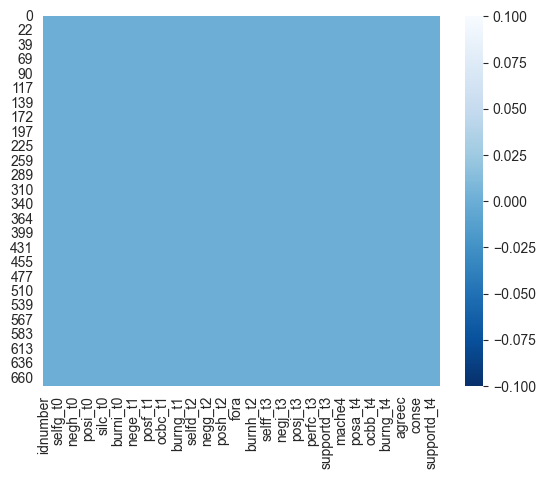

In [10]:
# Visualizes missing values in a heatmap after the deletaion
sns.heatmap(df1.isnull(), cmap='Blues_r');

### FACTOR ANALYSIS - PREPARATION

In [11]:
# Check the description of the data
df1.describe()
df1

,idnumber,workexperience,age,nationality,gender,selfa_t0,selfb_t0,selfc_t0,selfd_t0,selfe_t0,...,supporta_t4,supportb_t4,supportc_t4,supportd_t4,opena,openb,openc,opend,opene,openf
0,1,1,23,1,0,3,3,3,3,2,...,4,4,4,4,4,3,2,3,3,2
3,4,1,22,1,0,4,3,4,3,3,...,5,5,5,5,5,5,5,5,5,4
4,5,1,22,1,1,4,4,3,3,3,...,5,5,5,5,5,5,5,5,5,4
7,8,1,22,1,0,2,4,4,4,4,...,4,4,4,4,1,1,1,1,1,1
8,9,1,23,12,1,3,2,2,3,2,...,4,4,4,4,4,4,3,4,3,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
665,666,2,23,12,0,4,4,4,4,4,...,3,3,4,4,5,5,5,5,5,5
671,672,1,20,10,1,2,3,3,3,2,...,3,4,4,4,4,3,2,4,4,3
672,673,2,21,15,1,4,3,4,3,3,...,5,5,5,5,5,5,3,5,4,3
673,674,1,22,21,0,4,3,4,4,4,...,4,4,4,4,4,4,4,4,4,3


In [12]:
# Select all the columns that we are going to use for the model
df2 = df1[["posa_t0","posb_t0","posc_t0","posd_t0","pose_t0", "posf_t0","posg_t0","posh_t0","posi_t0","posj_t0",
           "supporta_t1","supportb_t1","supportc_t1","supportd_t1",
           "enga_t2","engb_t2","engc_t2",
           "ocba_t3", "ocbb_t3", "ocbc_t3"]]
df2

,posa_t0,posb_t0,posc_t0,posd_t0,pose_t0,posf_t0,posg_t0,posh_t0,posi_t0,posj_t0,supporta_t1,supportb_t1,supportc_t1,supportd_t1,enga_t2,engb_t2,engc_t2,ocba_t3,ocbb_t3,ocbc_t3
0,3,3,4,3,3,3,3,4,4,3,4,4,4,4,3,3,3,4,4,4
3,5,4,4,5,4,3,4,5,5,5,4,3,5,5,4,4,4,5,5,5
4,5,4,4,5,3,3,4,5,4,5,5,5,4,5,5,5,4,5,5,5
7,1,1,2,2,2,1,5,4,2,3,5,5,4,4,5,5,5,4,4,4
8,3,4,3,3,3,4,4,3,4,3,4,4,4,4,3,3,3,4,4,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
665,3,3,4,4,3,1,4,4,3,3,4,4,4,4,3,5,5,5,5,5
671,4,3,2,4,3,2,2,4,4,3,5,5,4,3,2,3,2,5,5,5
672,5,4,5,5,4,4,5,5,5,5,5,5,5,5,3,3,3,5,5,5
673,4,4,4,4,3,4,4,5,5,4,4,4,4,4,3,3,3,5,5,5


In [13]:
# Apply coerce
df2 = df2.apply(pd.to_numeric, errors="coerce")
df2.dtypes

posa_t0        int64
posb_t0        int64
posc_t0        int64
posd_t0        int64
pose_t0        int64
posf_t0        int64
posg_t0        int64
posh_t0        int64
posi_t0        int64
posj_t0        int64
supporta_t1    int64
supportb_t1    int64
supportc_t1    int64
supportd_t1    int64
enga_t2        int64
engb_t2        int64
engc_t2        int64
ocba_t3        int64
ocbb_t3        int64
ocbc_t3        int64
dtype: object

In [14]:
# Drop NA
df2 = df2.dropna()

In [15]:
# Correlation Matrix
df2.corr()

,posa_t0,posb_t0,posc_t0,posd_t0,pose_t0,posf_t0,posg_t0,posh_t0,posi_t0,posj_t0,supporta_t1,supportb_t1,supportc_t1,supportd_t1,enga_t2,engb_t2,engc_t2,ocba_t3,ocbb_t3,ocbc_t3
posa_t0,1.000000,0.348778,0.235127,0.445910,0.173835,0.067511,0.195763,0.330375,0.371853,0.357353,-0.021159,0.016594,0.041395,0.096173,0.016176,0.088765,0.180092,0.030348,0.027307,0.036198
posb_t0,0.348778,1.000000,0.226478,0.611385,0.309654,0.065109,0.272289,0.268668,0.168318,0.314432,0.017467,0.080452,0.103092,0.050905,0.122151,0.117880,0.137726,0.072567,0.097449,0.031804
posc_t0,0.235127,0.226478,1.000000,0.279208,0.400601,0.144650,0.317441,0.363181,0.191144,0.327078,-0.053875,-0.054937,-0.041286,0.028506,0.092004,0.148327,0.126974,0.074719,0.012235,0.032014
posd_t0,0.445910,0.611385,0.279208,1.000000,0.293357,0.113742,0.346533,0.388937,0.319477,0.375663,0.003683,0.073529,0.112932,0.090295,0.152342,0.221132,0.224160,0.051709,0.104606,0.034949
pose_t0,0.173835,0.309654,0.400601,0.293357,1.000000,0.186521,0.289411,0.335045,0.136854,0.276970,-0.067576,-0.033866,-0.067902,-0.025518,0.023041,0.056083,0.048935,0.021688,-0.003113,-0.016200
posf_t0,0.067511,0.065109,0.144650,0.113742,0.186521,1.000000,0.068182,0.113668,0.257095,0.081948,-0.072152,-0.144003,-0.124739,0.028495,0.045260,-0.012787,-0.053737,0.011098,0.056032,-0.006478
posg_t0,0.195763,0.272289,0.317441,0.346533,0.289411,0.068182,1.000000,0.360124,0.191405,0.286392,0.089862,0.130540,0.100978,0.111058,0.083773,0.165650,0.208317,0.062002,0.073526,0.090237
posh_t0,0.330375,0.268668,0.363181,0.388937,0.335045,0.113668,0.360124,1.000000,0.447063,0.508542,0.007186,0.091449,0.032698,0.084419,0.046252,0.114801,0.103544,0.022546,0.027562,0.095443
posi_t0,0.371853,0.168318,0.191144,0.319477,0.136854,0.257095,0.191405,0.447063,1.000000,0.360270,0.097765,0.084515,0.095346,0.117865,-0.006559,0.051577,0.151235,0.039567,0.036689,0.058000
posj_t0,0.357353,0.314432,0.327078,0.375663,0.276970,0.081948,0.286392,0.508542,0.360270,1.000000,0.023118,0.063266,0.111380,0.157743,0.061727,0.169207,0.178511,0.061469,0.093540,0.104810


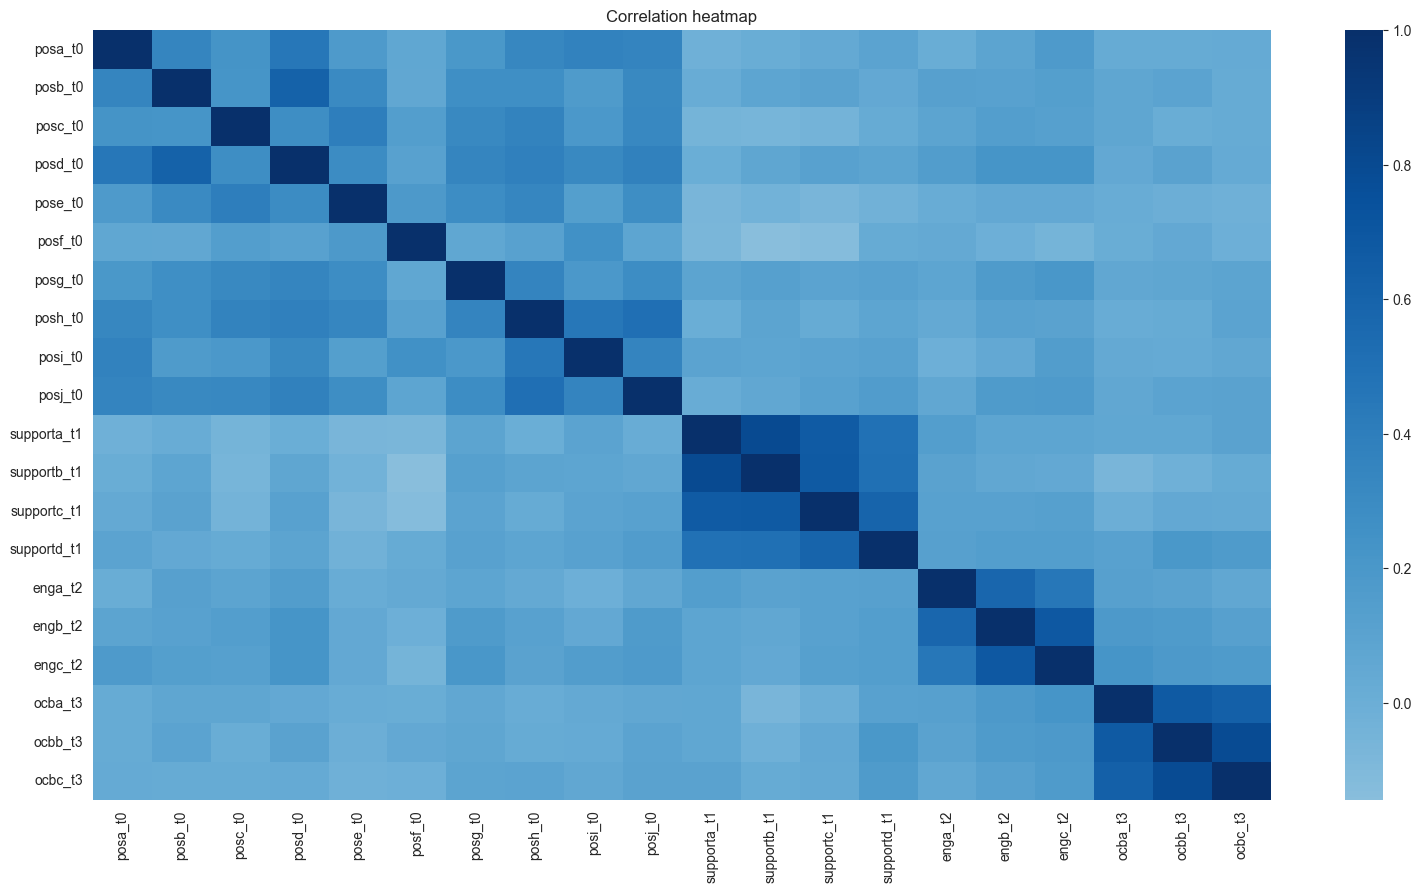

In [16]:
# Correlate the selected columns
df2.corr()
plt.figure(figsize=(19,10))
c = df2.corr()
sns.heatmap(c, cmap="Blues", center=0)
plt.title("Correlation heatmap")
plt.show()

### FACTOR ANALYSIS

In [17]:
# Check the eigenvalues to choose the number of factors
from factor_analyzer import FactorAnalyzer

fa_test = FactorAnalyzer(rotation=None)
fa_test.fit(df2)

ev, v = fa_test.get_eigenvalues()
ev

array([4.13418636, 2.91592586, 2.40739844, 1.76349643, 1.10339308,
       1.07953881, 0.96037254, 0.72022161, 0.66538328, 0.62435274,
       0.57577811, 0.51128031, 0.47087836, 0.41265414, 0.37449375,
       0.35144631, 0.30133046, 0.26266253, 0.18653732, 0.17866957])

In [18]:
# Check the value of eigenvalues sorted
sorted(ev)

[0.17866956887443725,
 0.18653731808808371,
 0.2626625257506517,
 0.3013304582845153,
 0.3514463116827593,
 0.3744937528043016,
 0.4126541426703849,
 0.4708783617945886,
 0.511280314331036,
 0.5757781085697845,
 0.6243527357554134,
 0.6653832821271208,
 0.7202216116535537,
 0.9603725365864997,
 1.0795388083759134,
 1.103393077837883,
 1.7634964286893307,
 2.4073984362801006,
 2.9159258588513266,
 4.134186360992315]

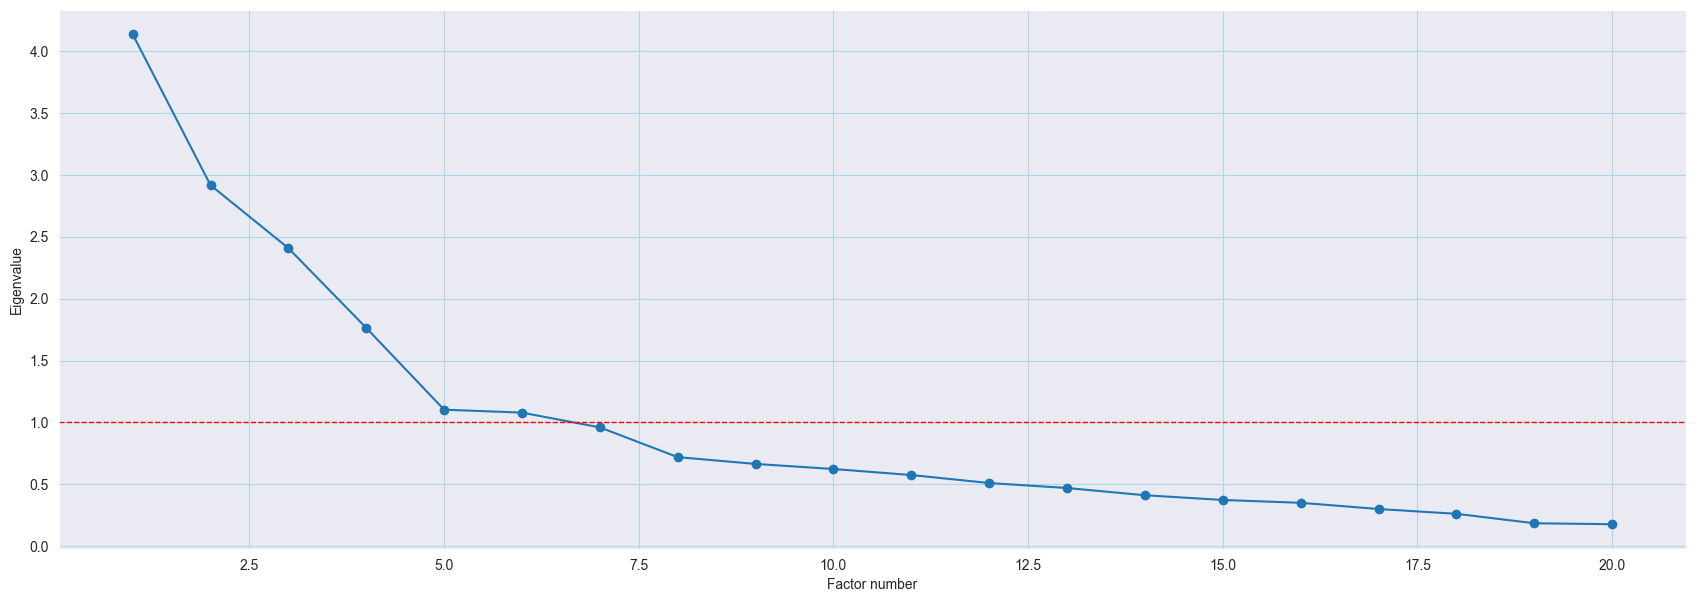

In [19]:
# Check the eigenvalues graphically

plt.figure(figsize=(21,7))
plt.scatter(range(1, len(ev) + 1), ev)
plt.plot(range(1, len(ev) + 1), ev)
plt.axhline(y=1, color='red', linestyle='--', linewidth=1)
plt.xlabel("Factor number")
plt.ylabel("Eigenvalue")
plt.grid(color='lightblue')
plt.show()

In [20]:
# Five factors were retained based on the scree plot and the Kaiser criterion. The first five factors have eigenvalues equal to or greater than 1,
# while the remaining factors explain little additional variance
from factor_analyzer import FactorAnalyzer

fa = FactorAnalyzer()
fa.set_params(n_factors=5,
rotation='varimax')
fa.fit(df2)
loadings = fa.loadings_
print(loadings)

[[ 0.02759003  0.46889563  0.00846007  0.05209156  0.25915105]
 [ 0.04569483  0.32054097  0.03724896  0.06935185  0.76205949]
 [-0.06770663  0.50870009  0.00807732  0.10723025  0.090052  ]
 [ 0.05386853  0.49413605  0.02220194  0.15976164  0.58389698]
 [-0.08373654  0.45024475 -0.02534274  0.01302158  0.18642235]
 [-0.10767673  0.24831321  0.02625938 -0.03600081 -0.01506465]
 [ 0.10768095  0.43606062  0.04385134  0.12938153  0.16347544]
 [ 0.0626676   0.74626102  0.01287506  0.02289021  0.02585844]
 [ 0.11540164  0.5576341   0.0255139   0.00150501 -0.00157239]
 [ 0.08947389  0.6224373   0.05998366  0.08909787  0.116799  ]
 [ 0.84605157 -0.04254848  0.04472596  0.05629861 -0.02881534]
 [ 0.87668233  0.00270341 -0.0666948   0.02004044  0.04520778]
 [ 0.81441822 -0.00639851 -0.00543064  0.08227969  0.08461395]
 [ 0.61823298  0.09864355  0.14985599  0.09840676 -0.01023186]
 [ 0.09753745  0.00796653  0.04436299  0.60482401  0.0718608 ]
 [ 0.04942303  0.10033458  0.08294029  0.93489607  0.02

In [21]:
# Performing factor analysis
pd.DataFrame(fa.loadings_, columns=['Factor1','Factor2','Factor3','Factor4','Factor5'],index=df2.columns)

,Factor1,Factor2,Factor3,Factor4,Factor5
posa_t0,0.027590,0.468896,0.008460,0.052092,0.259151
posb_t0,0.045695,0.320541,0.037249,0.069352,0.762059
posc_t0,-0.067707,0.508700,0.008077,0.107230,0.090052
posd_t0,0.053869,0.494136,0.022202,0.159762,0.583897
pose_t0,-0.083737,0.450245,-0.025343,0.013022,0.186422
posf_t0,-0.107677,0.248313,0.026259,-0.036001,-0.015065
posg_t0,0.107681,0.436061,0.043851,0.129382,0.163475
posh_t0,0.062668,0.746261,0.012875,0.022890,0.025858
posi_t0,0.115402,0.557634,0.025514,0.001505,-0.001572
posj_t0,0.089474,0.622437,0.059984,0.089098,0.116799


In [22]:
# Information about Variance, Proportional of total variance and cumulative proportion
variance_info = fa.get_factor_variance()

variance_df = pd.DataFrame(
    variance_info,
    columns=['Factor1','Factor2','Factor3','Factor4','Factor5'],
    index=['Variance','Proportional Var','Cumulative Var']
)

print(variance_df)

                   Factor1   Factor2   Factor3   Factor4   Factor5
Variance          2.620846  2.585634  2.158331  1.866995  1.099561
Proportional Var  0.131042  0.129282  0.107917  0.093350  0.054978
Cumulative Var    0.131042  0.260324  0.368241  0.461590  0.516568


### FINDINGS



##### Positive Affect t_0
The positive affect items (posa_t0, posb_t0, posc_t0, posd_t0, pose_t0, posf_t0, posh_t0, posi_t0) load strongly on Factor 2, suggesting that this factor captures positive emotional states.

##### Social Support t_1
All support items (supporta_t1, supportb_t1, supportc_t1, supportd_t1) load highly on Factor 1, indicating that this factor represents perceived social support.

##### Engagement t_2
Engagement items (enga_t2, engb_t2, engc_t2) show their highest loadings on Factor 4, representing work or task engagement.

##### Occupational Commitment t_3
The ocb items (ocba_t3, ocbb_t3, ocbc_t3) load highly on Factor 3, indicating a clear occupational or organizational commitment dimension.

#### Factor 5
Since Factor 5 was defined by only two items and was not statistically significant, it was excluded and the analysis was continued with four factors



### AFTER REDUCING TO FOUR FACTORS

In [23]:
# Run the Factor Analysis after deciding only keeping four factores
from factor_analyzer import FactorAnalyzer

fa = FactorAnalyzer()
fa.set_params(n_factors=4,
rotation='varimax')
fa.fit(df2)
loadings = fa.loadings_
print(loadings)

[[ 0.54286911  0.0242059   0.00656056  0.04704721]
 [ 0.54501066  0.05375921  0.02733995  0.09635495]
 [ 0.50756735 -0.07452143  0.0101635   0.09187308]
 [ 0.67385091  0.0568768   0.01684359  0.16635663]
 [ 0.49472582 -0.08828884 -0.02610967  0.00453676]
 [ 0.22077994 -0.11202441  0.02811463 -0.04534581]
 [ 0.47470381  0.10328072  0.04389952  0.12056207]
 [ 0.67617095  0.04918924  0.01891894  0.00364351]
 [ 0.50474658  0.10347852  0.02982181 -0.01524781]
 [ 0.621205    0.08029013  0.06232651  0.07201549]
 [-0.04307914  0.84601745  0.04594259  0.05478324]
 [ 0.02910563  0.87817682 -0.06691008  0.02025974]
 [ 0.03780368  0.81465611 -0.00633664  0.08486157]
 [ 0.09426395  0.61486597  0.15125908  0.09264673]
 [ 0.04458189  0.09875966  0.0431658   0.61001993]
 [ 0.11398746  0.0489371   0.08508828  0.92160496]
 [ 0.17072626  0.06728027  0.14356596  0.71068416]
 [ 0.03879145 -0.00615528  0.72258782  0.14260916]
 [ 0.04971139  0.04871616  0.90934876  0.08536377]
 [ 0.04978354  0.07596847  0.85

In [24]:
# Performing factor analysis
pd.DataFrame(fa.loadings_, columns=['Factor1', 'Factor2', 'Factor3', 'Factor4'], index=df2.columns)

,Factor1,Factor2,Factor3,Factor4
posa_t0,0.542869,0.024206,0.006561,0.047047
posb_t0,0.545011,0.053759,0.027340,0.096355
posc_t0,0.507567,-0.074521,0.010163,0.091873
posd_t0,0.673851,0.056877,0.016844,0.166357
pose_t0,0.494726,-0.088289,-0.026110,0.004537
posf_t0,0.220780,-0.112024,0.028115,-0.045346
posg_t0,0.474704,0.103281,0.043900,0.120562
posh_t0,0.676171,0.049189,0.018919,0.003644
posi_t0,0.504747,0.103479,0.029822,-0.015248
posj_t0,0.621205,0.080290,0.062327,0.072015


In [25]:
# Information about Variance, Proportional of total variance and cumulative proportion after the four factors change
variance_info = fa.get_factor_variance()

variance_df = pd.DataFrame(
    variance_info,
    columns=['Factor1','Factor2','Factor3','Factor4'],
    index=['Variance','Proportional Var','Cumulative Var']
)

print(variance_df)

                   Factor1   Factor2   Factor3   Factor4
Variance          2.983756  2.616372  2.152817  1.844482
Proportional Var  0.149188  0.130819  0.107641  0.092224
Cumulative Var    0.149188  0.280006  0.387647  0.479871


### FINDINGS



##### Positive Affect t_0
The positive affect items (posa_t0, posb_t0, posc_t0, posd_t0, pose_t0, posf_t0, posh_t0, posi_t0) load strongly on Factor 1, suggesting that this factor captures positive emotional states.

##### Social Support t_1
All support items (supporta_t1, supportb_t1, supportc_t1, supportd_t1) load highly on Factor 2, indicating that this factor represents perceived social support.

##### Engagement t_2
Engagement items (enga_t2, engb_t2, engc_t2) show their highest loadings on Factor 4, representing work or task engagement.

##### Occupational Commitment t_3
The ocb items (ocba_t3, ocbb_t3, ocbc_t3) load highly on Factor 3, indicating a clear occupational or organizational commitment dimension.


### FACTOR ANALYSIS - REFINING YOR DATASET

In [26]:
# Even if Factor 4 contributes the least to the total variance, all its items present factor loadings above 0.50. Therefore, no items were removed from Factor 4.
# Item elimination was based exclusively on factor loadings below 0.50 in other factors, in this case "posf_t0"

df3 = df2.drop("posf_t0", axis="columns")
df3


,posa_t0,posb_t0,posc_t0,posd_t0,pose_t0,posg_t0,posh_t0,posi_t0,posj_t0,supporta_t1,supportb_t1,supportc_t1,supportd_t1,enga_t2,engb_t2,engc_t2,ocba_t3,ocbb_t3,ocbc_t3
0,3,3,4,3,3,3,4,4,3,4,4,4,4,3,3,3,4,4,4
3,5,4,4,5,4,4,5,5,5,4,3,5,5,4,4,4,5,5,5
4,5,4,4,5,3,4,5,4,5,5,5,4,5,5,5,4,5,5,5
7,1,1,2,2,2,5,4,2,3,5,5,4,4,5,5,5,4,4,4
8,3,4,3,3,3,4,3,4,3,4,4,4,4,3,3,3,4,4,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
665,3,3,4,4,3,4,4,3,3,4,4,4,4,3,5,5,5,5,5
671,4,3,2,4,3,2,4,4,3,5,5,4,3,2,3,2,5,5,5
672,5,4,5,5,4,5,5,5,5,5,5,5,5,3,3,3,5,5,5
673,4,4,4,4,3,4,5,5,4,4,4,4,4,3,3,3,5,5,5


In [27]:
# Creating a new dataframe for efficacy construct alone
df4=df3[["posa_t0","posb_t0","posc_t0","posd_t0","pose_t0","posg_t0","posh_t0","posi_t0","posj_t0"]]
df4

,posa_t0,posb_t0,posc_t0,posd_t0,pose_t0,posg_t0,posh_t0,posi_t0,posj_t0
0,3,3,4,3,3,3,4,4,3
3,5,4,4,5,4,4,5,5,5
4,5,4,4,5,3,4,5,4,5
7,1,1,2,2,2,5,4,2,3
8,3,4,3,3,3,4,3,4,3
...,...,...,...,...,...,...,...,...,...
665,3,3,4,4,3,4,4,3,3
671,4,3,2,4,3,2,4,4,3
672,5,4,5,5,4,5,5,5,5
673,4,4,4,4,3,4,5,5,4


In [28]:
#Calculating reliabily
pg.cronbach_alpha(data=df4)

(0.8035662673214675, array([0.77 , 0.834]))

#### After the drop of "posf_t0" the results of Cronbanch´s alpha is good (0.8035), the extraversion scale shows good internal consistency, so there is no strong statistical need to drop more elements

### FACTOR ANALYSIS / CALCULATE RELIABILITY

In [29]:
# Calculate CA to review the internal consistency of the extraversion items

Positive_affect=df3[["posa_t0","posb_t0","posc_t0","posd_t0","pose_t0","posg_t0","posh_t0","posi_t0","posj_t0"]]
Positive_affect_CA=pg.cronbach_alpha(data=Positive_affect)

Social_support = df3[["supporta_t1","supportb_t1","supportc_t1","supportd_t1"]]
Social_support_CA =pg.cronbach_alpha(data=Social_support)

Engagement = df3[["enga_t2","engb_t2","engc_t2"]]
Engagement_CA = pg.cronbach_alpha(data=Engagement)

Org_citizen = df3[["ocba_t3", "ocbb_t3", "ocbc_t3"]]
Org_citizen_CA = pg.cronbach_alpha(data=Org_citizen)

print("The CA values for Positive effect are:", Positive_affect_CA)
print("The CA values for Social Support are:", Social_support_CA)
print("The CA values for Engagement are:", Engagement_CA)
print("The CA values for Organizational citizen are:", Org_citizen_CA)


The CA values for Positive effect are: (0.8035662673214675, array([0.77 , 0.834]))
The CA values for Social Support are: (0.867960175142777, array([0.843, 0.89 ]))
The CA values for Engagement are: (0.7987032141062336, array([0.758, 0.834]))
The CA values for Organizational citizen are: (0.8705069359966471, array([0.844, 0.893]))


After calculating Cronbach’s alpha, all constructs showed good internal consistency. Social Support (α = 0.87), Positive Affect (α = 0.80), Organizational Citizenship Behavior (α = 0.87), and Engagement (α = 0.80) exceeded the commonly accepted threshold of 0.70. Therefore, no items were removed at this stage, as all scales demonstrated satisfactory reliability.

In [30]:
# "posf_t0" is best to remove to imporve the reliability, we will remove them from the initial dataframe, df1

df1=df1.drop("posf_t0", axis="columns")

#### CREATE CONSTRUCTS

In [31]:
# Review df1
df1.head(5)

,idnumber,workexperience,age,nationality,gender,selfa_t0,selfb_t0,selfc_t0,selfd_t0,selfe_t0,...,supporta_t4,supportb_t4,supportc_t4,supportd_t4,opena,openb,openc,opend,opene,openf
0,1,1,23,1,0,3,3,3,3,2,...,4,4,4,4,4,3,2,3,3,2
3,4,1,22,1,0,4,3,4,3,3,...,5,5,5,5,5,5,5,5,5,4
4,5,1,22,1,1,4,4,3,3,3,...,5,5,5,5,5,5,5,5,5,4
7,8,1,22,1,0,2,4,4,4,4,...,4,4,4,4,1,1,1,1,1,1
8,9,1,23,12,1,3,2,2,3,2,...,4,4,4,4,4,4,3,4,3,3


In [32]:
# converting data types to the float data type
df1 = df1.astype('float')
df1.head(5)

,idnumber,workexperience,age,nationality,gender,selfa_t0,selfb_t0,selfc_t0,selfd_t0,selfe_t0,...,supporta_t4,supportb_t4,supportc_t4,supportd_t4,opena,openb,openc,opend,opene,openf
0,1.0,1.0,23.0,1.0,0.0,3.0,3.0,3.0,3.0,2.0,...,4.0,4.0,4.0,4.0,4.0,3.0,2.0,3.0,3.0,2.0
3,4.0,1.0,22.0,1.0,0.0,4.0,3.0,4.0,3.0,3.0,...,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,4.0
4,5.0,1.0,22.0,1.0,1.0,4.0,4.0,3.0,3.0,3.0,...,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,4.0
7,8.0,1.0,22.0,1.0,0.0,2.0,4.0,4.0,4.0,4.0,...,4.0,4.0,4.0,4.0,1.0,1.0,1.0,1.0,1.0,1.0
8,9.0,1.0,23.0,12.0,1.0,3.0,2.0,2.0,3.0,2.0,...,4.0,4.0,4.0,4.0,4.0,4.0,3.0,4.0,3.0,3.0


In [33]:
# Create new columns to aggregate the average of the mean of

df1["Positive_affect"] = df1["posa_t0"] + df1["posb_t0"] + df1["posc_t0"] + df1["posd_t0"] + df1["pose_t0"] + df1["posg_t0"] + df1["posh_t0"] + df1["posi_t0"] + df1["posj_t0"]
df1["Positive_affect_avg"] = df1["Positive_affect"]/9

df1["Social_support"] =df1["supporta_t1"] + df1["supportb_t1"] + df1["supportc_t1"] + df1["supportd_t1"]
df1["Social_support_avg"] = df1["Social_support"]/4

df1["Engagement"] =df1["enga_t2"] + df1["engb_t2"] + df1["engc_t2"]
df1["Engagement_avg"] = df1["Engagement"]/3

df1["Org_citizen"] =df1["ocba_t3"] + df1["ocbb_t3"] + df1["ocbc_t3"]
df1["Org_citizen_avg"] = df1["Org_citizen"]/3

print("The mean for Positive effect is:", df1["Positive_affect_avg"].mean())
print("The mean for Social Support are:", df1["Social_support_avg"].mean())
print("The mean for Engagement are:", df1["Engagement_avg"].mean())
print("The mean for Organizational citizen are:", df1["Org_citizen_avg"].mean())

The mean for Positive effect is: 3.950803212851405
The mean for Social Support are: 4.083584337349397
The mean for Engagement are: 3.516064257028113
The mean for Organizational citizen are: 4.085341365461847


In [34]:
df1.head(5)

,idnumber,workexperience,age,nationality,gender,selfa_t0,selfb_t0,selfc_t0,selfd_t0,selfe_t0,...,opene,openf,Positive_affect,Positive_affect_avg,Social_support,Social_support_avg,Engagement,Engagement_avg,Org_citizen,Org_citizen_avg
0,1.0,1.0,23.0,1.0,0.0,3.0,3.0,3.0,3.0,2.0,...,3.0,2.0,30.0,3.333333,16.0,4.00,9.0,3.000000,12.0,4.0
3,4.0,1.0,22.0,1.0,0.0,4.0,3.0,4.0,3.0,3.0,...,5.0,4.0,41.0,4.555556,17.0,4.25,12.0,4.000000,15.0,5.0
4,5.0,1.0,22.0,1.0,1.0,4.0,4.0,3.0,3.0,3.0,...,5.0,4.0,39.0,4.333333,19.0,4.75,14.0,4.666667,15.0,5.0
7,8.0,1.0,22.0,1.0,0.0,2.0,4.0,4.0,4.0,4.0,...,1.0,1.0,22.0,2.444444,18.0,4.50,15.0,5.000000,12.0,4.0
8,9.0,1.0,23.0,12.0,1.0,3.0,2.0,2.0,3.0,2.0,...,3.0,3.0,30.0,3.333333,16.0,4.00,9.0,3.000000,12.0,4.0


In [35]:
# Create a dataset with the attributes
df10 = df1[["idnumber", "workexperience", "age", "nationality", "gender", "Positive_affect_avg", "Social_support_avg", "Engagement_avg", "Org_citizen_avg"]]
df10

,idnumber,workexperience,age,nationality,gender,Positive_affect_avg,Social_support_avg,Engagement_avg,Org_citizen_avg
0,1.0,1.0,23.0,1.0,0.0,3.333333,4.00,3.000000,4.0
3,4.0,1.0,22.0,1.0,0.0,4.555556,4.25,4.000000,5.0
4,5.0,1.0,22.0,1.0,1.0,4.333333,4.75,4.666667,5.0
7,8.0,1.0,22.0,1.0,0.0,2.444444,4.50,5.000000,4.0
8,9.0,1.0,23.0,12.0,1.0,3.333333,4.00,3.000000,4.0
...,...,...,...,...,...,...,...,...,...
665,666.0,2.0,23.0,12.0,0.0,3.444444,4.00,4.333333,5.0
671,672.0,1.0,20.0,10.0,1.0,3.222222,4.25,2.333333,5.0
672,673.0,2.0,21.0,15.0,1.0,4.777778,5.00,3.000000,5.0
673,674.0,1.0,22.0,21.0,0.0,4.111111,4.00,3.000000,5.0


#### OUTLIERS

C:\Users\ricar\PycharmProjects\PythonProject1\.venv1\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


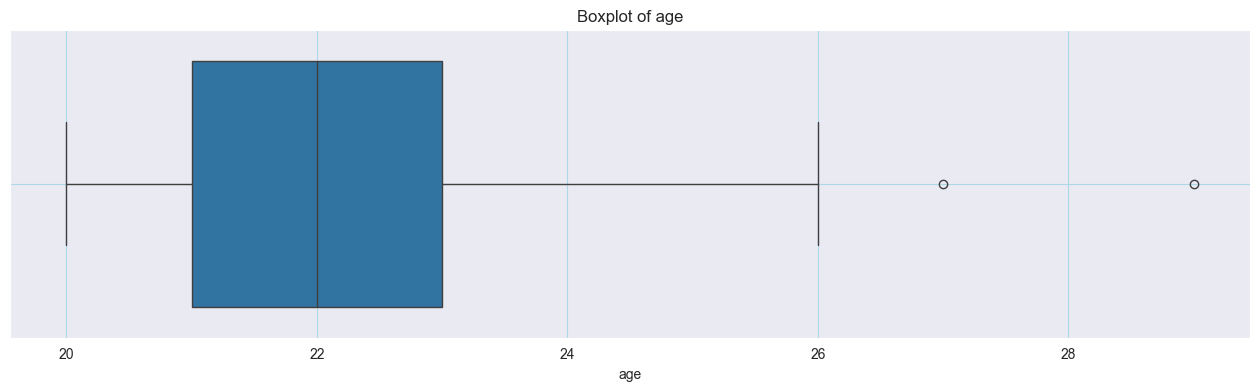

C:\Users\ricar\PycharmProjects\PythonProject1\.venv1\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


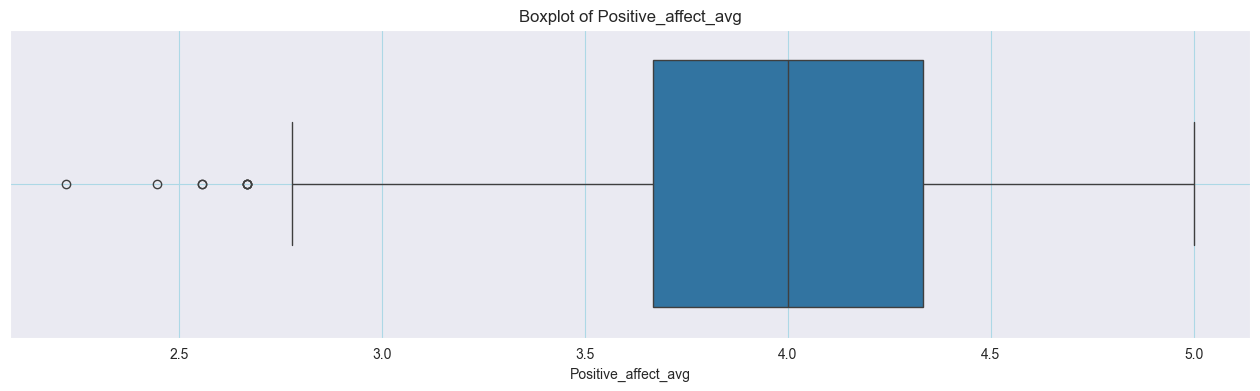

C:\Users\ricar\PycharmProjects\PythonProject1\.venv1\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


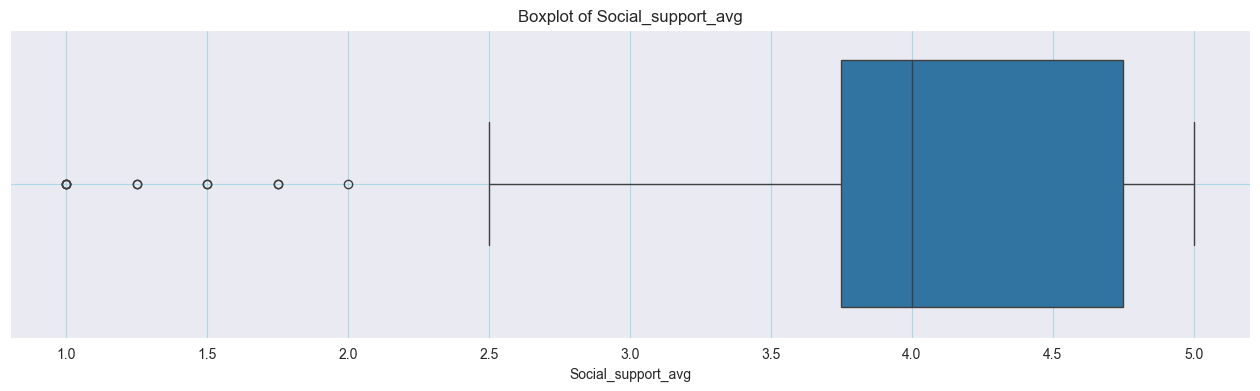

C:\Users\ricar\PycharmProjects\PythonProject1\.venv1\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


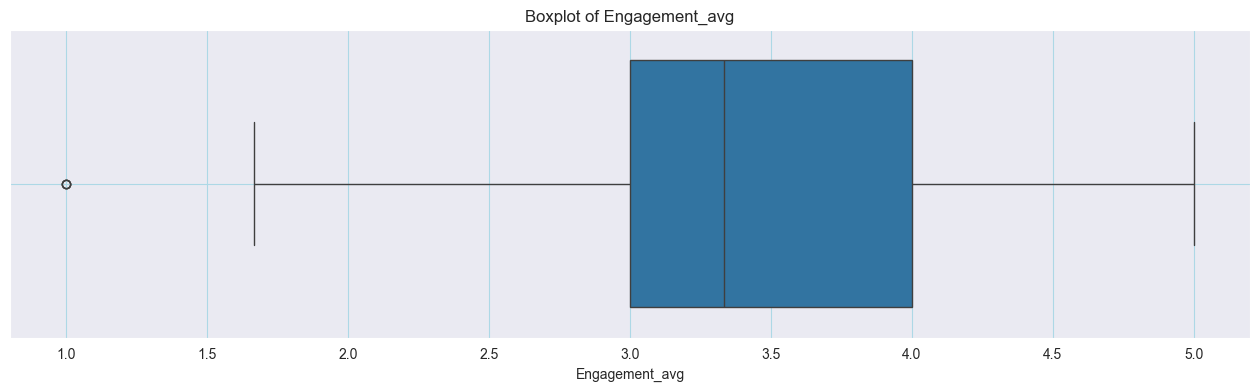

C:\Users\ricar\PycharmProjects\PythonProject1\.venv1\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


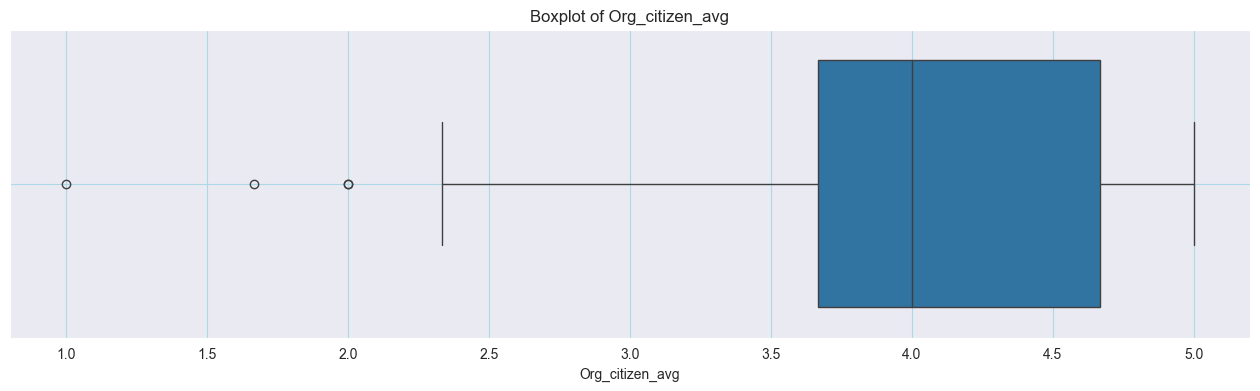

In [36]:
# Using the function to plot the average to check the outliers
def boxplot(column):
    fig, ax = plt.subplots(figsize=(16, 4))
    sns.boxplot(data=df10, x=df10[f"{column}"], color="#1f77b4")
    plt.title(f"Boxplot of {column}")
    plt.grid(color='lightblue')
    plt.show()

boxplot("age")
boxplot("Positive_affect_avg")
boxplot("Social_support_avg")
boxplot("Engagement_avg")
boxplot("Org_citizen_avg")

In [37]:
# Clean the outliers
df11 = df10[
    (df10["age"] <= 26) &
    (df10["Positive_affect_avg"] >= 2.7) &
    (df10["Social_support_avg"] >= 2.8) &
    (df10["Engagement_avg"] >= 1.6) &
    (df10["Org_citizen_avg"] >= 2.4)
].copy()

C:\Users\ricar\PycharmProjects\PythonProject1\.venv1\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


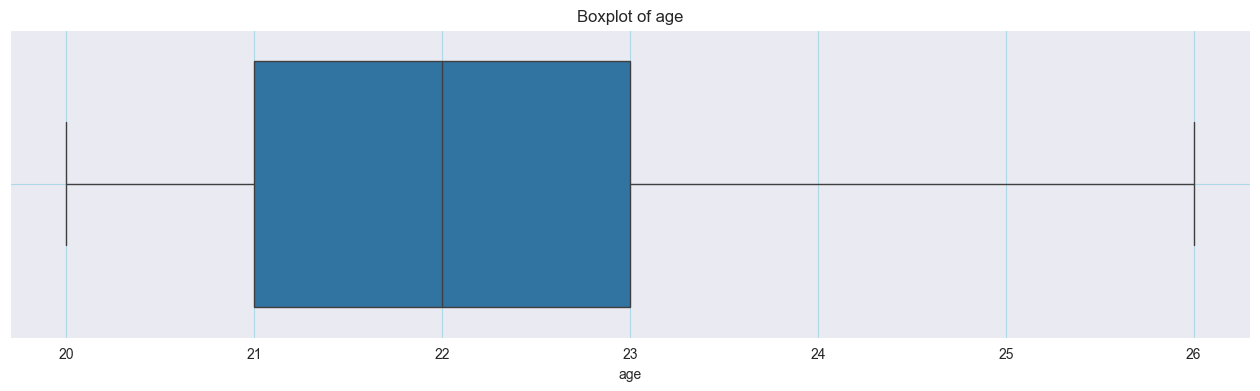

C:\Users\ricar\PycharmProjects\PythonProject1\.venv1\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


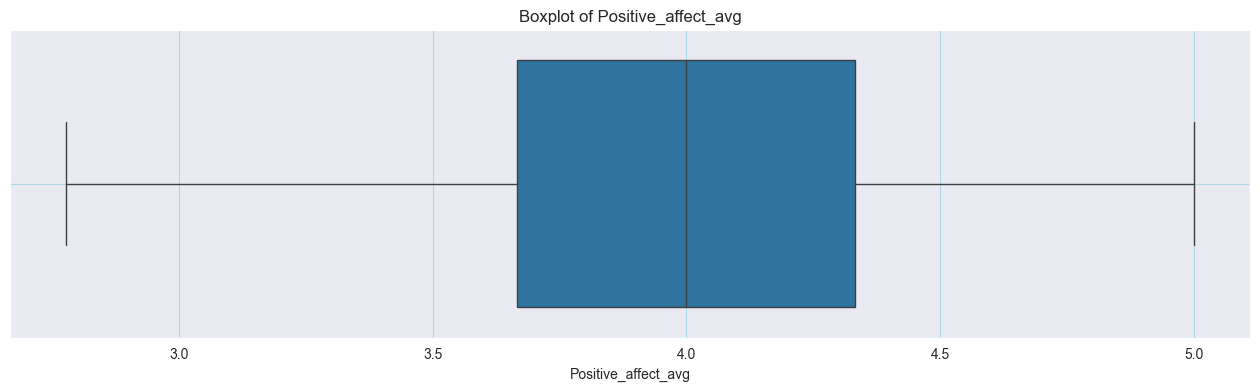

C:\Users\ricar\PycharmProjects\PythonProject1\.venv1\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


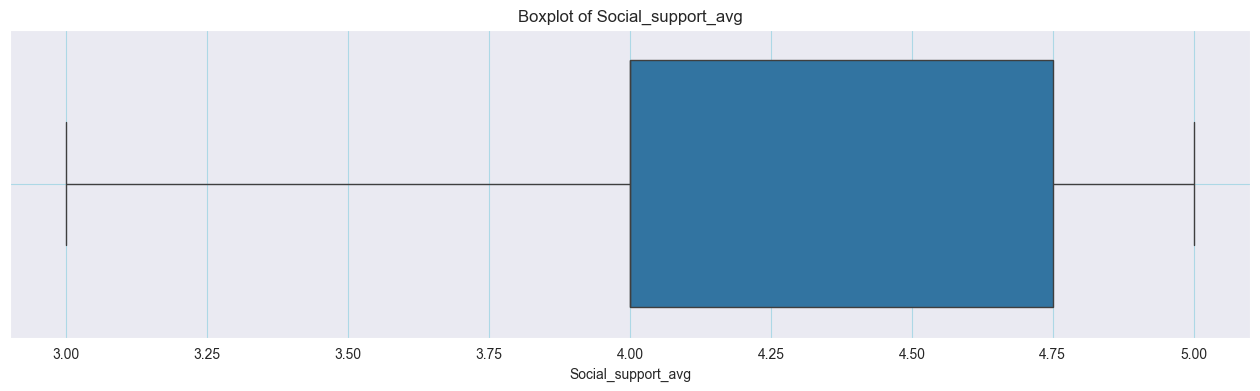

C:\Users\ricar\PycharmProjects\PythonProject1\.venv1\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


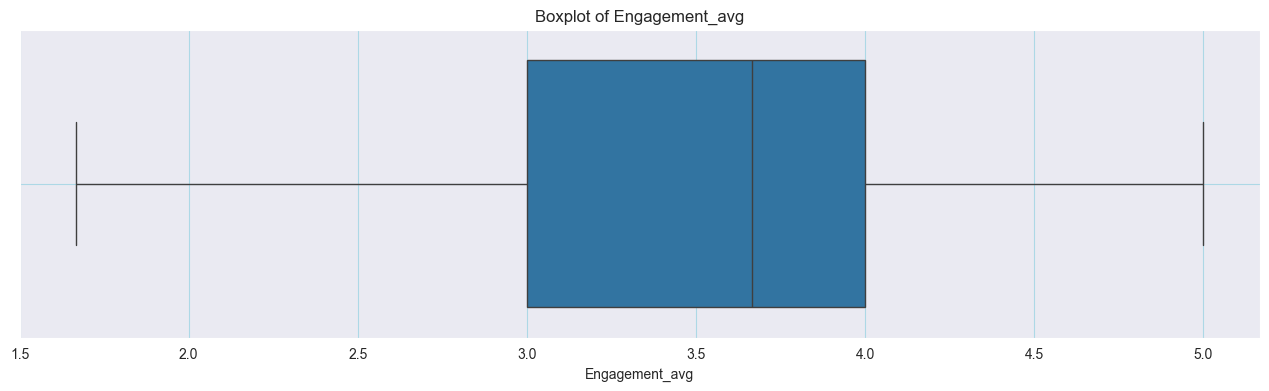

C:\Users\ricar\PycharmProjects\PythonProject1\.venv1\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


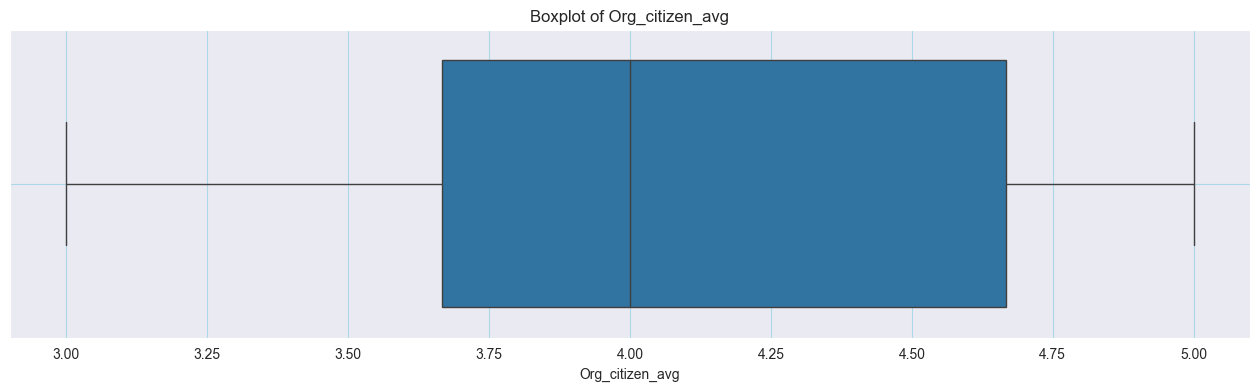

In [38]:
# Check the boxplots are free of outliers
def boxplot(column):
    fig, ax = plt.subplots(figsize=(16, 4))
    sns.boxplot(data=df11, x=df11[f"{column}"], color="#1f77b4")
    plt.title(f"Boxplot of {column}")
    plt.grid(color='lightblue')
    plt.show()

boxplot("age")
boxplot("Positive_affect_avg")
boxplot("Social_support_avg")
boxplot("Engagement_avg")
boxplot("Org_citizen_avg")

In [39]:
# Review the new dataset clean of outliers
df11.describe()

,idnumber,workexperience,age,nationality,gender,Positive_affect_avg,Social_support_avg,Engagement_avg,Org_citizen_avg
count,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000
mean,339.380471,1.104377,22.185185,4.653199,0.555556,3.977553,4.224747,3.548822,4.127946
std,203.153084,0.306265,1.134256,7.258564,0.497743,0.473077,0.559578,0.707605,0.642654
min,1.000000,1.000000,20.000000,1.000000,0.000000,2.777778,3.000000,1.666667,3.000000
25%,155.000000,1.000000,21.000000,1.000000,0.000000,3.666667,4.000000,3.000000,3.666667
50%,342.000000,1.000000,22.000000,1.000000,1.000000,4.000000,4.000000,3.666667,4.000000
75%,527.000000,1.000000,23.000000,5.000000,1.000000,4.333333,4.750000,4.000000,4.666667
max,675.000000,2.000000,26.000000,36.000000,1.000000,5.000000,5.000000,5.000000,5.000000


In [40]:
# Review the correlation matrix of the new dataset
df11.corr()

,idnumber,workexperience,age,nationality,gender,Positive_affect_avg,Social_support_avg,Engagement_avg,Org_citizen_avg
idnumber,1.000000,0.082871,0.054424,0.155675,0.050791,-0.113687,-0.029641,0.007442,-0.008888
workexperience,0.082871,1.000000,0.070598,0.174388,0.039399,-0.043363,0.049929,-0.010603,0.012021
age,0.054424,0.070598,1.000000,0.229002,-0.111037,0.059540,0.031345,0.178816,0.050810
nationality,0.155675,0.174388,0.229002,1.000000,-0.048417,0.069327,0.069368,0.038059,0.043825
gender,0.050791,0.039399,-0.111037,-0.048417,1.000000,0.027632,0.120284,-0.043697,-0.061022
Positive_affect_avg,-0.113687,-0.043363,0.059540,0.069327,0.027632,1.000000,0.111645,0.184570,0.130889
Social_support_avg,-0.029641,0.049929,0.031345,0.069368,0.120284,0.111645,1.000000,0.195808,0.128011
Engagement_avg,0.007442,-0.010603,0.178816,0.038059,-0.043697,0.184570,0.195808,1.000000,0.243762
Org_citizen_avg,-0.008888,0.012021,0.050810,0.043825,-0.061022,0.130889,0.128011,0.243762,1.000000


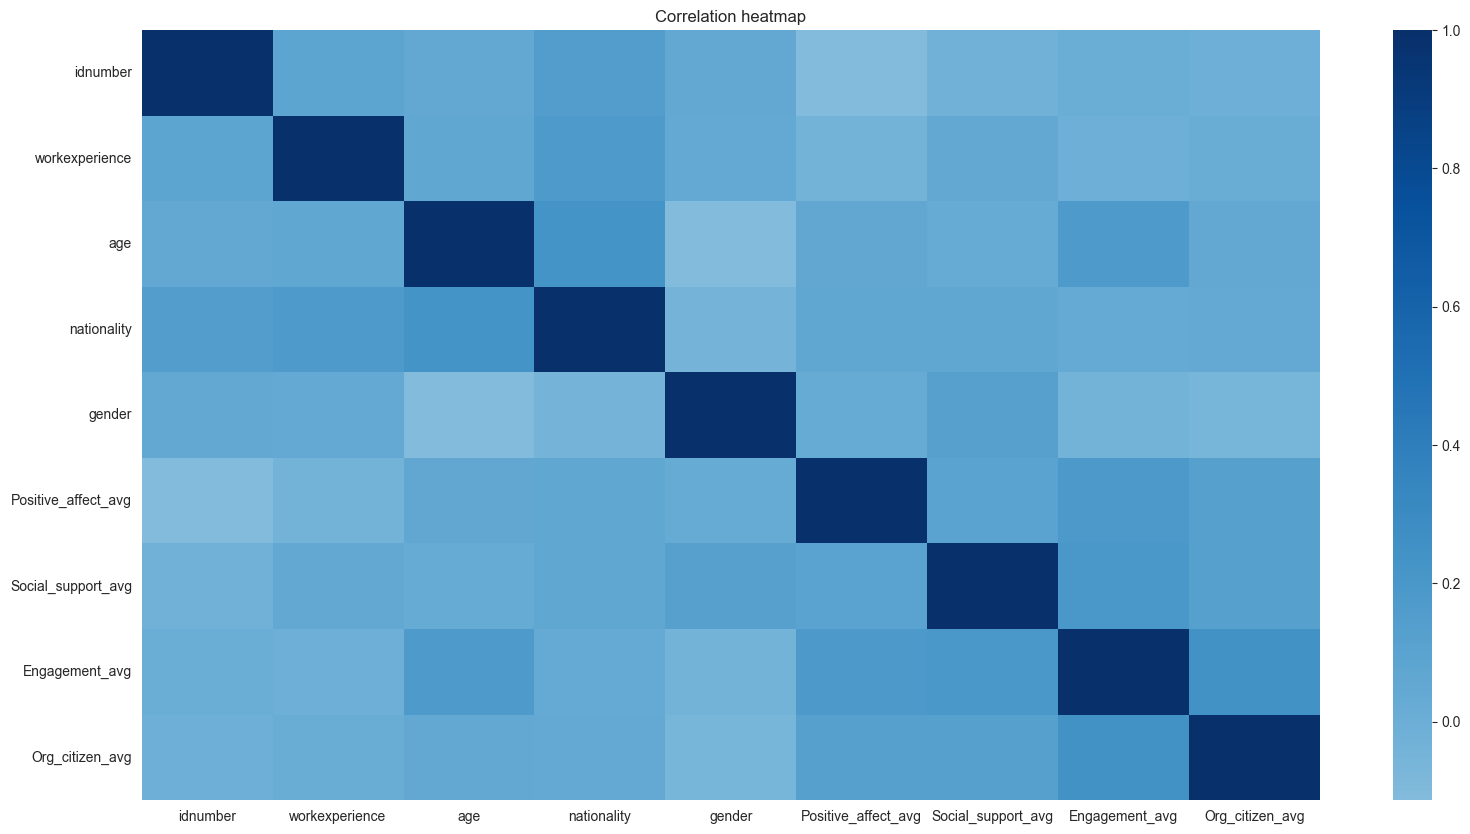

In [41]:
# Correlate the selected columns
df11.corr()
plt.figure(figsize=(19,10))
c = df11.corr()
sns.heatmap(c, cmap="Blues", center=0)
plt.title("Correlation heatmap")
plt.show()

In [42]:
# MODEL 8
p = Process(data=df11, model=8, x="Social_support_avg",w="Positive_affect_avg", y="Org_citizen_avg", m=["Engagement_avg"], controls=["workexperience", "age", "nationality", "gender"], center=True, boot=10000)
p.summary()


Process successfully initialized.
Based on the Process Macro by Andrew F. Hayes, Ph.D. (www.afhayes.com)


****************************** SPECIFICATION ****************************

Model = 8

Variables:
    Cons = Cons
    x = Social_support_avg
    w = Positive_affect_avg
    y = Org_citizen_avg
    m1 = Engagement_avg
Statistical Controls:
 workexperience, age, nationality, gender


Mean-centered variables:
 Positive_affect_avg, Social_support_avg



Sample size:
297

Bootstrapping information for indirect effects:
Final number of bootstrap samples: 10000
Number of samples discarded due to convergence issues: 0

***************************** OUTCOME MODELS ****************************

Outcome = Org_citizen_avg 
OLS Regression Summary

     R²  Adj. R²    MSE      F  df1  df2  p-value
 0.0778   0.0489 0.3914 3.0381    8  288   0.0027

Coefficients

                                         coeff     se       t      p    LLCI   ULCI
Cons                                    3.5482 0.747

C:\Users\ricar\PycharmProjects\PythonProject1\.venv1\Lib\site-packages\pyprocessmacro\models.py:1188: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  return df.apply(pd.to_numeric, args=["ignore"])
C:\Users\ricar\PycharmProjects\PythonProject1\.venv1\Lib\site-packages\pyprocessmacro\models.py:1252: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  return df.apply(pd.to_numeric, args=["ignore"])
